In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

###Load Dataset

In [3]:
df=pd.read_csv("creditcard.csv")

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5974 entries, 0 to 5973
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    5974 non-null   int64  
 1   V1      5974 non-null   float64
 2   V2      5974 non-null   float64
 3   V3      5974 non-null   float64
 4   V4      5974 non-null   float64
 5   V5      5974 non-null   float64
 6   V6      5974 non-null   float64
 7   V7      5974 non-null   float64
 8   V8      5974 non-null   float64
 9   V9      5974 non-null   float64
 10  V10     5974 non-null   float64
 11  V11     5974 non-null   float64
 12  V12     5974 non-null   float64
 13  V13     5974 non-null   float64
 14  V14     5974 non-null   float64
 15  V15     5974 non-null   float64
 16  V16     5974 non-null   float64
 17  V17     5974 non-null   float64
 18  V18     5973 non-null   float64
 19  V19     5973 non-null   float64
 20  V20     5973 non-null   float64
 21  V21     5973 non-null   float64
 22  

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,5974.000000,5974.000000,5974.000000,5974.000000,5974.000000,5974.000000,5974.000000,5974.000000,5974.000000,5974.000000,...,5973.000000,5973.000000,5973.000000,5973.000000,5973.000000,5973.000000,5973.000000,5973.000000,5973.000000,5973.000000
mean,2677.615501,-0.266159,0.285505,0.844231,0.104200,0.000709,0.194948,0.018324,-0.039006,0.396916,...,-0.043098,-0.161548,-0.036483,0.028960,0.089873,-0.040197,0.025234,0.006116,65.061811,0.000502
std,1765.025532,1.395405,1.208867,1.031448,1.442339,1.185900,1.365525,1.059870,1.304005,1.047749,...,0.883330,0.646380,0.373210,0.619810,0.407680,0.488284,0.364482,0.265131,192.490314,0.022407
min,0.000000,-12.168192,-15.732974,-12.389545,-4.657545,-32.092129,-7.465603,-12.968670,-23.632502,-3.336805,...,-11.468435,-8.454599,-7.996811,-2.512377,-2.322906,-1.338556,-7.976100,-2.909294,0.000000,0.000000
25%,1162.250000,-1.015749,-0.280054,0.295701,-0.839417,-0.609206,-0.677720,-0.492968,-0.189736,-0.264280,...,-0.260507,-0.594625,-0.187108,-0.350226,-0.152744,-0.399334,-0.049681,-0.017776,4.450000,0.000000
50%,2537.000000,-0.420703,0.346083,0.882882,0.161767,-0.083983,-0.142606,0.041761,0.037831,0.360826,...,-0.111701,-0.177197,-0.046772,0.094946,0.106290,-0.079583,0.015976,0.019417,15.620000,0.000000
75%,3781.750000,1.115402,0.941548,1.504158,1.071412,0.441406,0.605784,0.566306,0.343067,0.961662,...,0.059809,0.273148,0.088154,0.435670,0.355157,0.245560,0.155281,0.082701,56.660000,0.000000
max,6645.000000,1.685314,7.467017,4.101716,6.013346,10.658654,21.393069,34.303177,3.877662,9.272376,...,22.580675,4.393846,4.095021,3.200201,1.972515,3.463246,3.852046,4.860769,7712.430000,1.000000


###Check Missing Values

In [7]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [19]:
df = df.dropna()

###Check Class Distribution

In [18]:
df['Class'].value_counts()

,count
Class,
0.0,5970
1.0,3


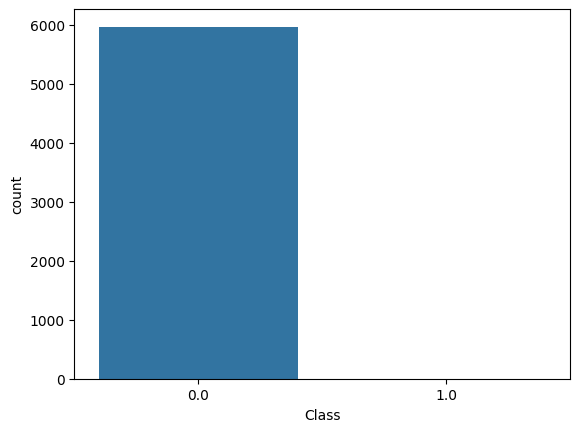

In [17]:
sns.countplot(x='Class', data=df)
plt.show()

###Separate Features and Target

In [12]:
X = df.drop('Class', axis=1)
y = df['Class']

###Scale Features

In [13]:
scaler = StandardScaler()

X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time'] = scaler.fit_transform(X[['Time']])

###Split Dataset

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
import pandas as pd


train_df = pd.concat([X_train, y_train], axis=1)
train_df_cleaned = train_df.dropna()

# Separate X_train and y_train again after cleaning
X_train_cleaned = train_df_cleaned.drop(columns=['Class'])
y_train_cleaned = train_df_cleaned['Class']

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_cleaned, y_train_cleaned)

LogisticRegression(max_iter=1000)

In [25]:
y_pred_lr = lr.predict(X_test)

####Evaluate Logistic Regression

In [26]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.999163179916318


In [27]:
print(confusion_matrix(y_test, y_pred_lr))

[[1194    0]
 [   1    0]]


In [28]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1194
         1.0       0.00      0.00      0.00         1

    accuracy                           1.00      1195
   macro avg       0.50      0.50      0.50      1195
weighted avg       1.00      1.00      1.00      1195



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


####Train Decision Tree Model

In [34]:
dtc = DecisionTreeClassifier()

dtc.fit(X_train_cleaned, y_train_cleaned)

DecisionTreeClassifier()

In [35]:
y_pred_dt = dtc.predict(X_test)

####Evaluate Decision Tree

In [36]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

Accuracy: 0.998326359832636


In [37]:
print(confusion_matrix(y_test, y_pred_dt))

[[1193    1]
 [   1    0]]


In [38]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1194
         1.0       0.00      0.00      0.00         1

    accuracy                           1.00      1195
   macro avg       0.50      0.50      0.50      1195
weighted avg       1.00      1.00      1.00      1195



###Compare Models

In [39]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:",
      accuracy_score(y_test, y_pred_lr))

print("Decision Tree:",
      accuracy_score(y_test, y_pred_dt))


Logistic Regression: 0.999163179916318
Decision Tree: 0.998326359832636


###Apply Anomaly Detection

In [40]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.001,
    random_state=42
)

pred = iso.fit_predict(X)

pred = np.where(pred == -1, 1, 0)

In [43]:

nan_mask = y.notna()
y_cleaned = y[nan_mask]
pred_cleaned = pred[nan_mask.values]
print(confusion_matrix(y_cleaned, pred_cleaned))

[[5964    6]
 [   3    0]]


In [45]:
print(classification_report(y_cleaned, pred_cleaned))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      5970
         1.0       0.00      0.00      0.00         3

    accuracy                           1.00      5973
   macro avg       0.50      0.50      0.50      5973
weighted avg       1.00      1.00      1.00      5973



###Calculate ROC-AUC Score

In [46]:
from sklearn.metrics import roc_auc_score

score = roc_auc_score(
    y_test,
    lr.predict_proba(X_test)[:,1]
)

print("ROC AUC Score:", score)

ROC AUC Score: 0.9807370184254607


In [48]:
from sklearn.metrics import roc_auc_score

score = roc_auc_score(
    y_test,
    dtc.predict_proba(X_test)[:,1]
)

print("ROC AUC Score:", score)

ROC AUC Score: 0.49958123953098826
